# 04 — Exploratory Data Analysis

Visual and statistical exploration of relationships between features and the `Diagnosis` target, using the shared plotting functions in `src/visualization.py`.

In [1]:
import sys
sys.path.insert(0, '..')
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from src.utils import RAW_DATA_PATH, TARGET_COL, NUMERIC_COLS, CATEGORICAL_COLS, BINARY_COLS
from src.data_validation import load_raw_data
from src.preprocessing import clean_data
from src import visualization as viz

df = load_raw_data(RAW_DATA_PATH)
df = clean_data(df)
df.shape

[09:11:24] INFO - src.data_validation - Loaded raw data: 2149 rows x 35 columns


[09:11:24] INFO - src.preprocessing - Dropped non-predictive columns: ['PatientID', 'DoctorInCharge']


(2149, 33)

## 4.1 Target Distribution

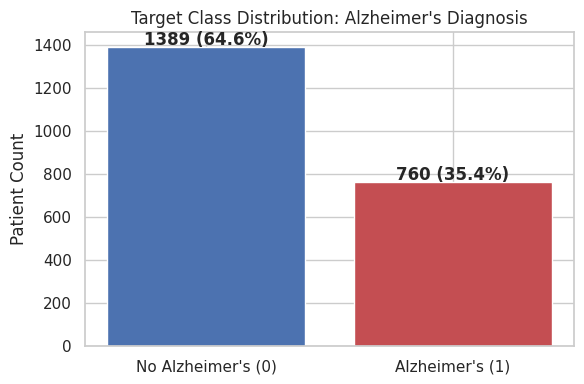

In [2]:
fig, ax = plt.subplots(figsize=(6, 4))
viz.plot_target_distribution(df, ax=ax)
plt.tight_layout()
plt.savefig('../reports/target_distribution.png', dpi=110)
plt.show()

## 4.2 Numeric Feature Distributions by Diagnosis

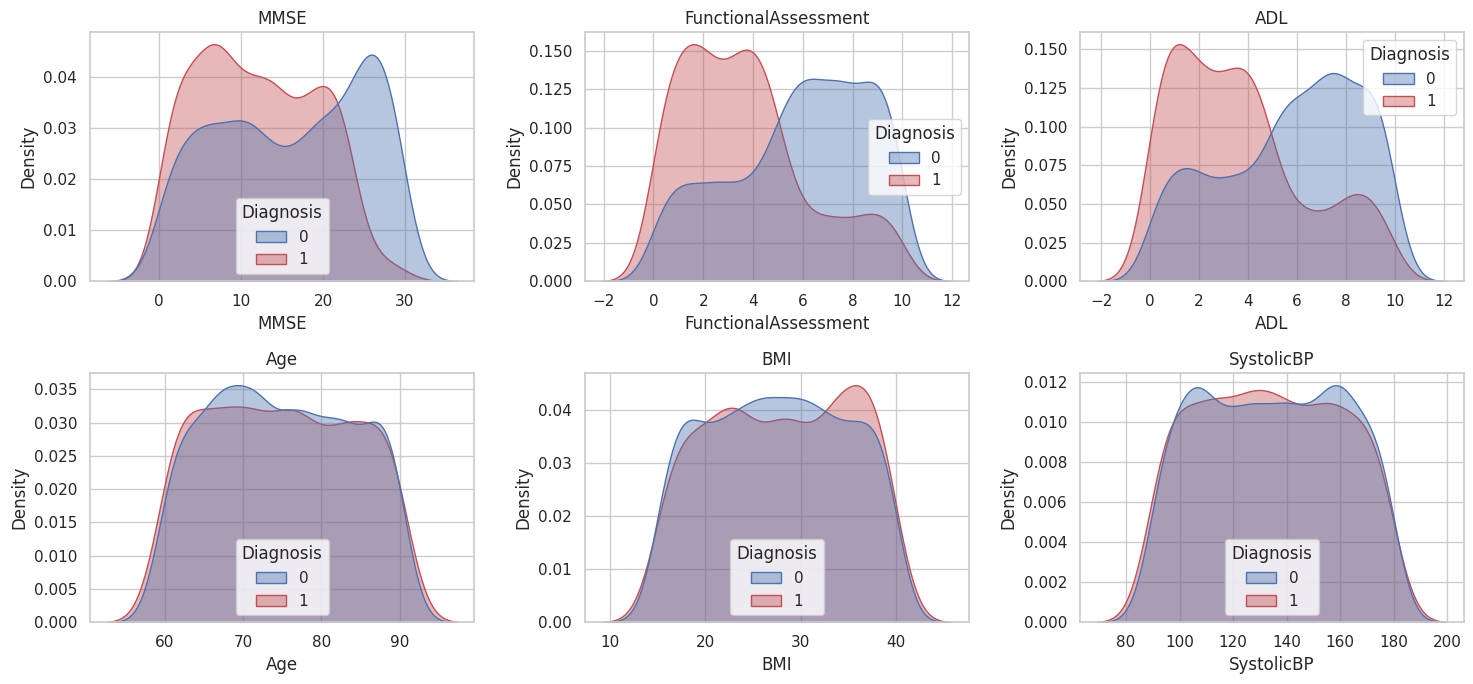

In [3]:
key_numeric = ['MMSE', 'FunctionalAssessment', 'ADL', 'Age', 'BMI', 'SystolicBP']
fig = viz.plot_numeric_distributions_by_target(df, key_numeric, ncols=3)
fig.savefig('../reports/numeric_distributions_by_target.png', dpi=110)
plt.show()

**Observation:** `MMSE`, `FunctionalAssessment`, and `ADL` show the clearest visual separation between the two diagnosis groups (as clinically expected — these are cognitive/functional assessment scores). `Age`, `BMI`, and `SystolicBP` show much weaker separation on their own, suggesting they may still add value in combination with other features (checked via feature importance in `06`/`07`), but aren't strong univariate predictors.

## 4.3 Correlation Heatmap

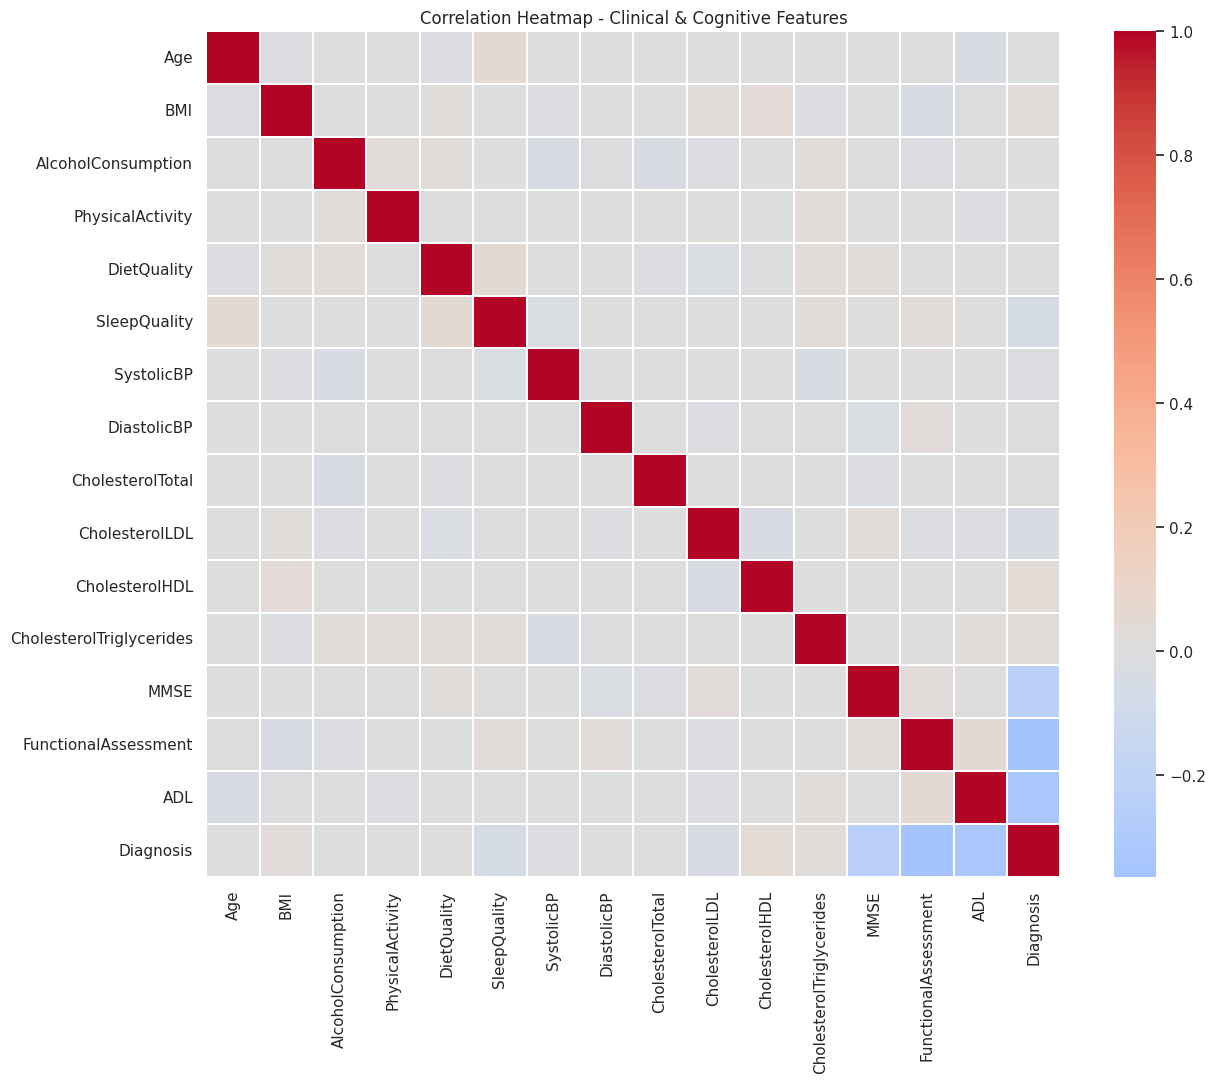

In [4]:
corr_cols = NUMERIC_COLS + [TARGET_COL]
fig, ax = plt.subplots(figsize=(13, 11))
viz.plot_correlation_heatmap(df, corr_cols, ax=ax)
plt.tight_layout()
plt.savefig('../reports/correlation_heatmap.png', dpi=110)
plt.show()

In [5]:
target_corr = df[NUMERIC_COLS + [TARGET_COL]].corr()[TARGET_COL].drop(TARGET_COL).sort_values(key=abs, ascending=False)
print("Numeric features ranked by |correlation| with Diagnosis:")
target_corr

Numeric features ranked by |correlation| with Diagnosis:


FunctionalAssessment       -0.364898
ADL                        -0.332346
MMSE                       -0.237126
SleepQuality               -0.056548
CholesterolHDL              0.042584
CholesterolLDL             -0.031976
BMI                         0.026343
CholesterolTriglycerides    0.022672
SystolicBP                 -0.015615
DietQuality                 0.008506
AlcoholConsumption         -0.007618
CholesterolTotal            0.006394
PhysicalActivity            0.005945
Age                        -0.005488
DiastolicBP                 0.005293
Name: Diagnosis, dtype: float64

## 4.4 Binary / Categorical Features vs Diagnosis

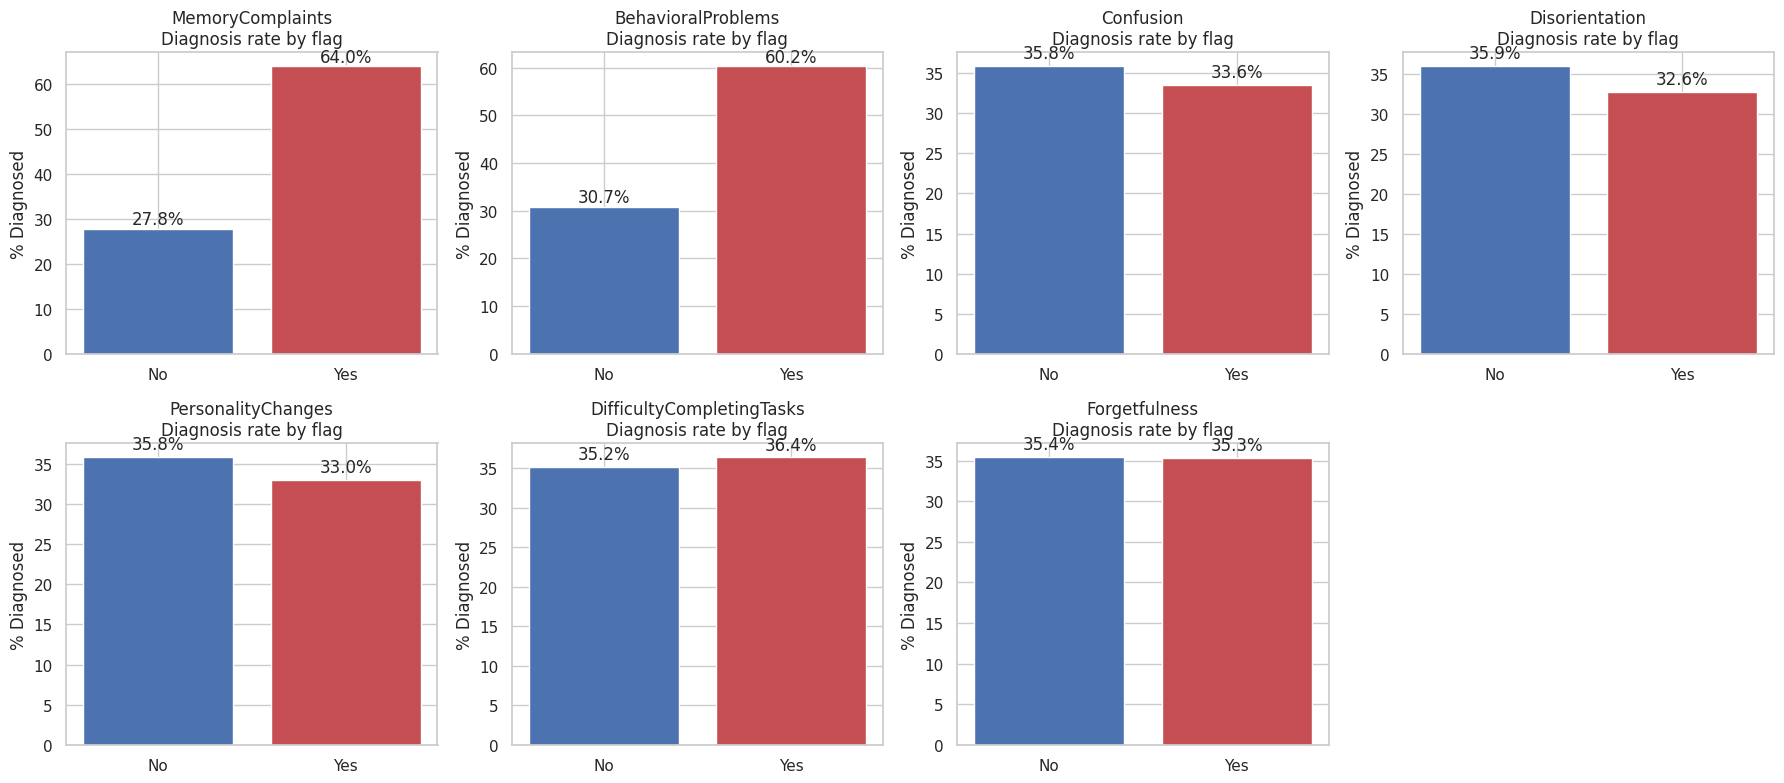

In [6]:
symptom_cols = ['MemoryComplaints', 'BehavioralProblems', 'Confusion', 'Disorientation',
                'PersonalityChanges', 'DifficultyCompletingTasks', 'Forgetfulness']

fig, axes = plt.subplots(2, 4, figsize=(18, 8))
axes = axes.flatten()
for i, col in enumerate(symptom_cols):
    rate = df.groupby(col)[TARGET_COL].mean() * 100
    axes[i].bar(['No', 'Yes'], rate.values, color=['#4C72B0', '#C44E52'])
    axes[i].set_title(f'{col}\nDiagnosis rate by flag')
    axes[i].set_ylabel('% Diagnosed')
    for j, v in enumerate(rate.values):
        axes[i].text(j, v + 1, f'{v:.1f}%', ha='center')
fig.delaxes(axes[-1])
plt.tight_layout()
plt.savefig('../reports/symptom_flags_vs_diagnosis.png', dpi=110)
plt.show()

**Observation:** Every behavioural/cognitive symptom flag (memory complaints, confusion, disorientation, personality changes, difficulty completing tasks, forgetfulness, behavioural problems) shows a markedly higher Alzheimer's diagnosis rate when present versus absent — consistent with clinical expectations and reassuring from a data-quality perspective (the labels behave the way domain knowledge predicts).

## 4.5 Medical History Risk Factors vs Diagnosis

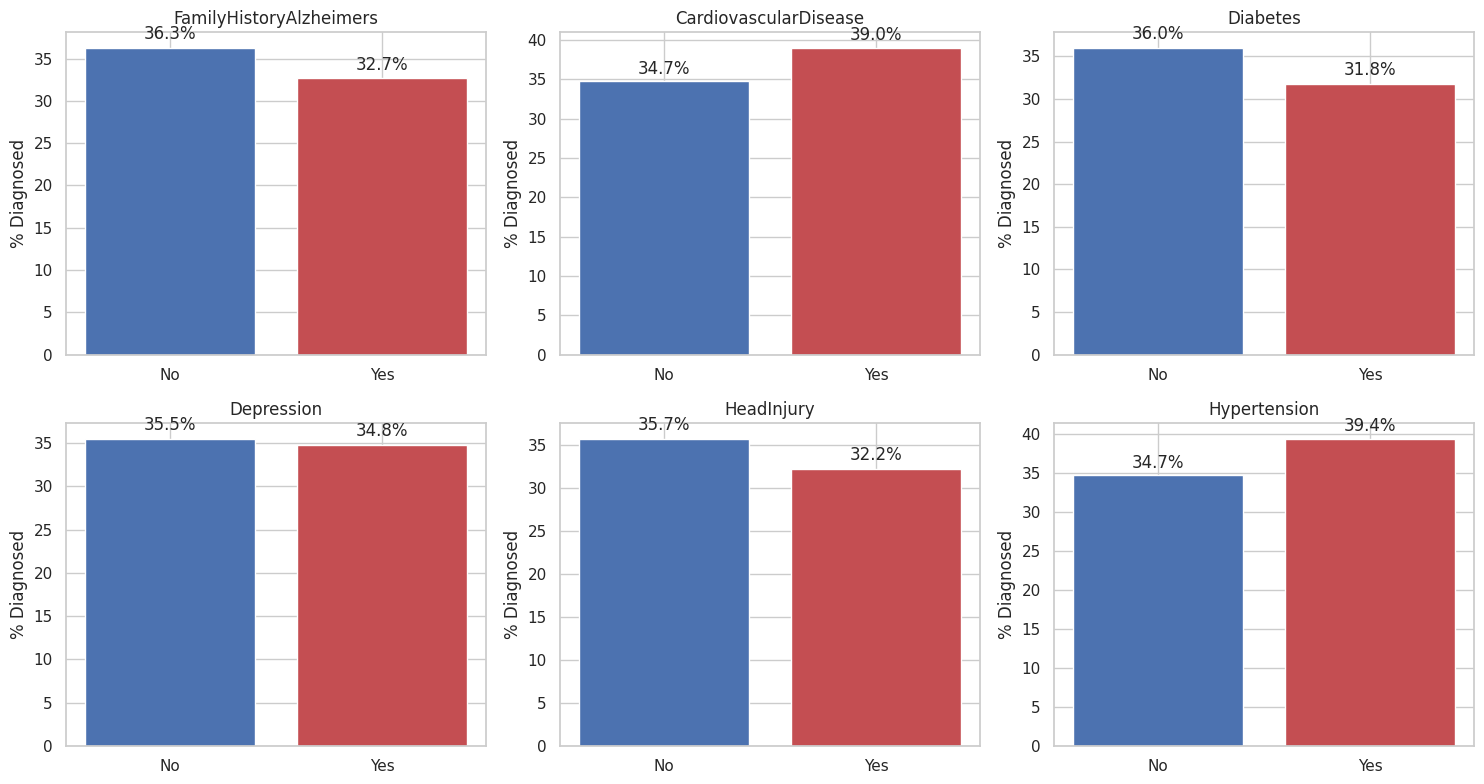

In [7]:
history_cols = ['FamilyHistoryAlzheimers', 'CardiovascularDisease', 'Diabetes', 'Depression', 'HeadInjury', 'Hypertension']
fig, axes = plt.subplots(2, 3, figsize=(15, 8))
axes = axes.flatten()
for i, col in enumerate(history_cols):
    rate = df.groupby(col)[TARGET_COL].mean() * 100
    axes[i].bar(['No', 'Yes'], rate.values, color=['#4C72B0', '#C44E52'])
    axes[i].set_title(col)
    axes[i].set_ylabel('% Diagnosed')
    for j, v in enumerate(rate.values):
        axes[i].text(j, v + 1, f'{v:.1f}%', ha='center')
plt.tight_layout()
plt.savefig('../reports/medical_history_vs_diagnosis.png', dpi=110)
plt.show()

**Observation:** Unlike the cognitive/behavioural symptom flags, the classic comorbidity risk factors (cardiovascular disease, diabetes, hypertension, family history, depression, head injury) show only small differences in diagnosis rate between groups in this dataset — the diagnosis rate hovers close to the ~35% base rate regardless of these flags. This is a useful signal for feature engineering: on their own these are weak predictors, so `05_Feature_Engineering.ipynb` combines several of them into a single `CardiometabolicRiskScore` to concentrate their weak individual signal into one feature, rather than relying on any single flag.

## 4.6 Demographics vs Diagnosis

/tmp/ipykernel_725/4282901960.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x=TARGET_COL, y='Age', ax=axes[0], palette=['#4C72B0', '#C44E52'])
/tmp/ipykernel_725/4282901960.py:5: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[0].set_xticklabels(['No', 'Yes'])


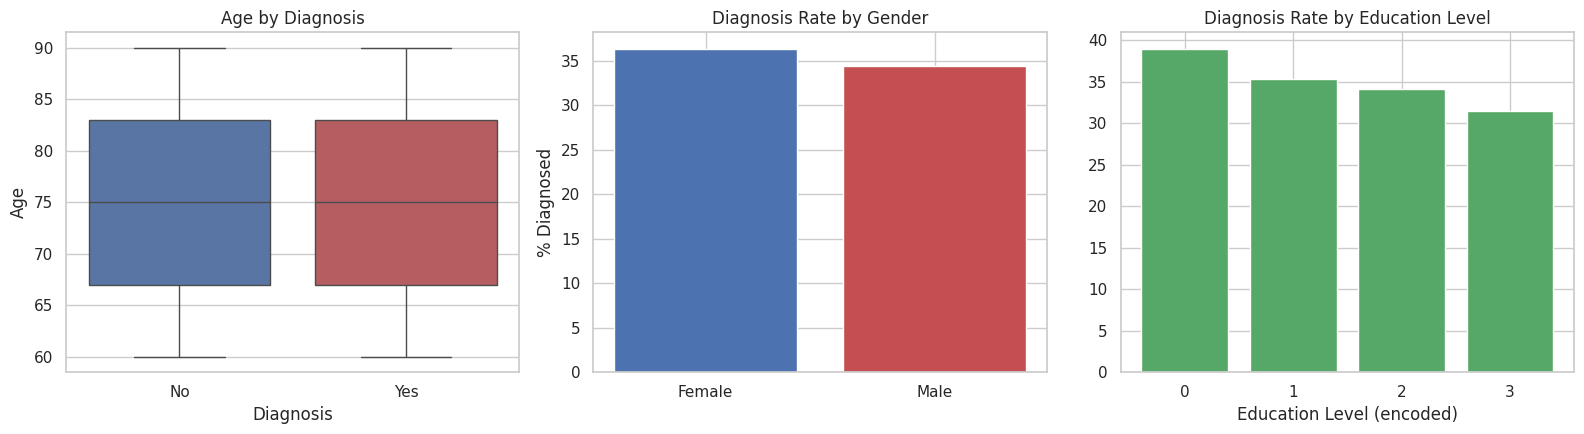

In [8]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))

sns.boxplot(data=df, x=TARGET_COL, y='Age', ax=axes[0], palette=['#4C72B0', '#C44E52'])
axes[0].set_title('Age by Diagnosis')
axes[0].set_xticklabels(['No', 'Yes'])

gender_rate = df.groupby('Gender')[TARGET_COL].mean() * 100
axes[1].bar(['Female', 'Male'], gender_rate.values, color=['#4C72B0', '#C44E52'])
axes[1].set_title('Diagnosis Rate by Gender')
axes[1].set_ylabel('% Diagnosed')

edu_rate = df.groupby('EducationLevel')[TARGET_COL].mean() * 100
axes[2].bar(edu_rate.index.astype(str), edu_rate.values, color='#55A868')
axes[2].set_title('Diagnosis Rate by Education Level')
axes[2].set_xlabel('Education Level (encoded)')

plt.tight_layout()
plt.savefig('../reports/demographics_vs_diagnosis.png', dpi=110)
plt.show()

## 4.7 EDA Summary

- **Strongest predictors (univariate):** `MMSE`, `FunctionalAssessment`, `ADL` — clinician-administered cognitive/functional scores show clear separation by diagnosis, and every behavioural/memory symptom flag raises diagnosis rate substantially when present.
- **Weak univariate predictors:** classic comorbidities (cardiovascular disease, diabetes, hypertension, family history) and demographics (age, gender, education) show only small marginal differences in this dataset — they likely still add value in combination, which is why tree-based ensemble models (which capture interactions) are expected to outperform simpler linear models.
- **Data quality reassurance:** symptom flags behave exactly as clinical domain knowledge predicts relative to the label, which is a good sign for label integrity.
- **Feature engineering direction:** combine weak comorbidity/lifestyle signals into composite scores (`CardiometabolicRiskScore`, `LifestyleProtectiveScore`) and combine the three strong cognitive scores into a single `CognitiveCompositeScore`, done next in `05_Feature_Engineering.ipynb`.